# MC Dropout: Uncertainty Estimation via Stochastic Forward Passes

Monte Carlo Dropout keeps dropout **enabled at inference time** and runs multiple
stochastic forward passes (T times). Each pass produces slightly different predictions.
The variance across passes gives us a measure of **model uncertainty**.

We compare T = 1, 2, 3, 5, 8, 13, and 21 forward passes.

In [1]:
import timm
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

NUM_CLASSES = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Must match training: drop_rate and drop_path_rate so DropPath layers exist (not Identity)
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES, drop_rate=0.2, drop_path_rate=0.2)
model.load_state_dict(torch.load("fids30_classifier_30cls_b0.pth", map_location=device))
model = model.to(device)

config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

class_names = test_ds.classes
print(f"Device: {device}")
print(f"Test samples: {len(test_ds)}")
print(f"Classes ({len(class_names)}): {class_names}")

Device: cuda
Test samples: 195
Classes (30): ['acerolas', 'apples', 'apricots', 'avocados', 'bananas', 'blackberries', 'blueberries', 'cantaloupes', 'cherries', 'coconuts', 'figs', 'grapefruits', 'grapes', 'guava', 'kiwifruit', 'lemons', 'limes', 'mangos', 'olives', 'oranges', 'passionfruit', 'peaches', 'pears', 'pineapples', 'plums', 'pomegranates', 'raspberries', 'strawberries', 'tomatoes', 'watermelons']


## 1. Enable Dropout at Inference Time

By default, `model.eval()` disables dropout. For MC Dropout, we call `model.eval()`
to freeze batch norm statistics, then selectively re-enable all dropout layers.

In [2]:
def enable_mc_dropout(model):
    """Set model to eval mode but re-enable all dropout-like layers (Dropout, DropPath, etc.)."""
    model.eval()
    for module in model.modules():
        classname = type(module).__name__
        if "Drop" in classname:
            module.train()
    return model

# Verify: find all drop-like layers by class name
dropout_layers = []
for n, m in model.named_modules():
    classname = type(m).__name__
    if "Drop" in classname:
        p = getattr(m, 'p', getattr(m, 'drop_prob', None))
        dropout_layers.append((n, classname, p))

print(f"Found {len(dropout_layers)} dropout-like layers")
for name, mtype, p in dropout_layers[:5]:
    print(f"  {name}: {mtype} (p={p})")
if len(dropout_layers) > 5:
    print(f"  ... and {len(dropout_layers)-5} more")

Found 15 dropout-like layers
  blocks.1.0.drop_path: DropPath (p=0.0125)
  blocks.1.1.drop_path: DropPath (p=0.025)
  blocks.2.0.drop_path: DropPath (p=0.037500000000000006)
  blocks.2.1.drop_path: DropPath (p=0.05)
  blocks.3.0.drop_path: DropPath (p=0.0625)
  ... and 10 more


## 2. Baseline: Standard Inference (Dropout Off)

In [3]:
model.eval()
all_preds_std = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        probs = F.softmax(model(images), dim=1)
        all_preds_std.append(probs.cpu())
        all_labels.append(labels)

all_preds_std = torch.cat(all_preds_std)
all_labels = torch.cat(all_labels)

std_acc = accuracy_score(all_labels, all_preds_std.argmax(1))
print(f"Standard inference accuracy: {std_acc:.2%}")

Standard inference accuracy: 78.97%


## 3. MC Dropout: T Stochastic Forward Passes

For each value of T, run T forward passes with dropout enabled, then average the
softmax outputs to get the mean prediction and compute the **variance across passes** as uncertainty.

In [ ]:
from tqdm.auto import tqdm

T_VALUES = [1, 2, 3, 5, 8, 13, 21] # he also tried T=100 but in terms of computation time that is not recommendeds

def mc_dropout_predict(model, loader, T, device):
    """Run T stochastic forward passes with dropout enabled.
    
    Returns:
        mean_probs: (N, C) mean softmax probabilities across T passes
        all_probs:  (T, N, C) individual softmax outputs per pass
    """
    enable_mc_dropout(model)
    
    pass_probs = []
    for t in tqdm(range(T), desc=f"MC Dropout T={T}", leave=False):
        batch_probs = []
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                probs = F.softmax(model(images), dim=1)
                batch_probs.append(probs.cpu())
        pass_probs.append(torch.cat(batch_probs))
    
    all_probs = torch.stack(pass_probs)    # (T, N, C)
    mean_probs = all_probs.mean(dim=0)     # (N, C)
    return mean_probs, all_probs


# Run MC Dropout for each T
mc_results = {}
for T in T_VALUES:
    mean_probs, all_probs = mc_dropout_predict(model, test_loader, T, device)
    preds = mean_probs.argmax(dim=1)
    acc = accuracy_score(all_labels, preds)
    
    # Uncertainty: mean variance of softmax across passes, normalized to [0, 1]
    pred_variance = all_probs.var(dim=0).mean(dim=1)  # (N,)
    vmax = pred_variance.max()
    if vmax > 0:
        pred_variance = pred_variance / vmax
    
    mc_results[T] = {
        "acc": acc,
        "mean_probs": mean_probs,
        "preds": preds,
        "pred_variance": pred_variance,
    }
    print(f"T={T:3d}: Accuracy={acc:.2%}, Mean Norm. Variance={pred_variance.mean():.4f}")

print(f"\nBaseline (no dropout): {std_acc:.2%}")

MC Dropout T=1:   0%|          | 0/1 [00:00<?, ?it/s]

T=  1: Accuracy=75.90%, Mean Norm. Variance=nan


/tmp/ipykernel_14828/584126379.py:37: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  pred_variance = all_probs.var(dim=0).mean(dim=1)  # (N,)


MC Dropout T=2:   0%|          | 0/2 [00:00<?, ?it/s]

T=  2: Accuracy=77.95%, Mean Norm. Variance=0.0678


...

T=  8: Accuracy=77.95%, Mean Norm. Variance=0.1115


MC Dropout T=13:   0%|          | 0/13 [00:00<?, ?it/s]

T= 13: Accuracy=78.97%, Mean Norm. Variance=0.2016


MC Dropout T=21:   0%|          | 0/21 [00:00<?, ?it/s]

T= 21: Accuracy=78.46%, Mean Norm. Variance=0.1762

Baseline (no dropout): 78.97%


## 4. Accuracy vs Number of Forward Passes

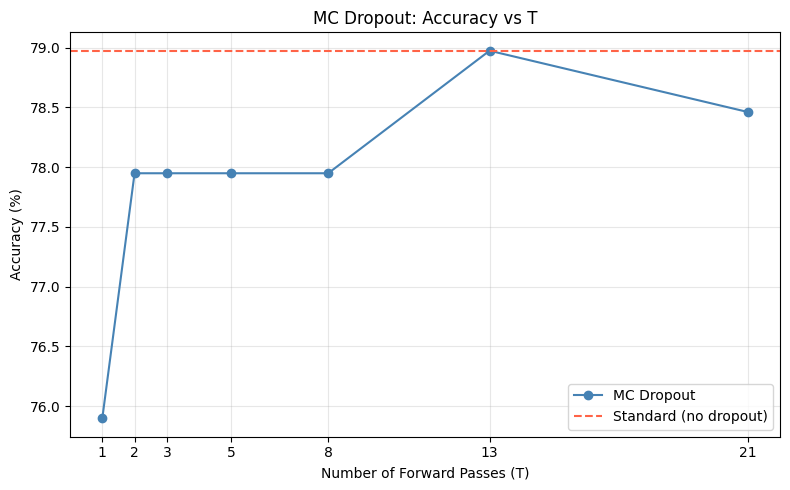

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

accs = [mc_results[T]["acc"] * 100 for T in T_VALUES]
ax.plot(T_VALUES, accs, 'o-', color='steelblue', label='MC Dropout')
ax.axhline(y=std_acc * 100, color='tomato', linestyle='--', label='Standard (no dropout)')

ax.set_xlabel("Number of Forward Passes (T)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("MC Dropout: Accuracy vs T")
ax.set_xticks(T_VALUES)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

his looked differently, the baseline accuracy was lower than the one of the models with the dropout (T >= 3)

## 5. Uncertainty Analysis: Correct vs Misclassified

Samples the model gets wrong should have **higher variance** across stochastic passes
than correct predictions. We verify this using T=21.

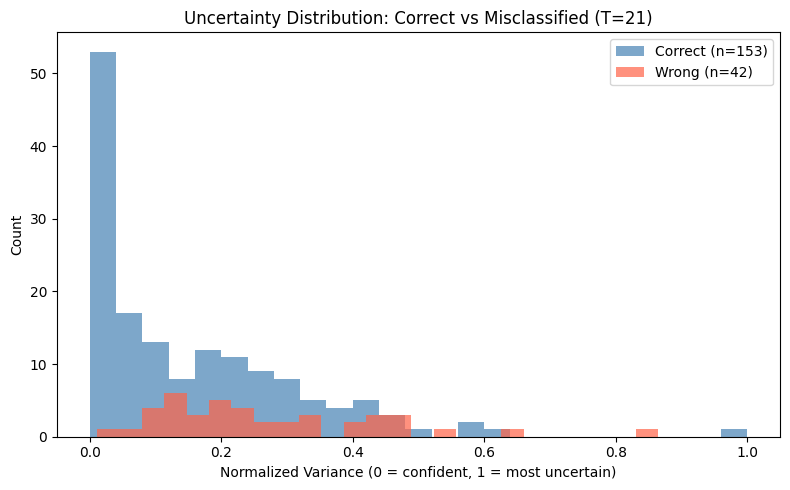

Mean norm. variance — Correct: 0.1507, Wrong: 0.2690


In [6]:
T_best = max(T_VALUES)
res = mc_results[T_best]
correct_mask = res["preds"] == all_labels

fig, ax = plt.subplots(figsize=(8, 5))

correct_vals = res["pred_variance"][correct_mask].numpy()
wrong_vals = res["pred_variance"][~correct_mask].numpy()

ax.hist(correct_vals, bins=25, alpha=0.7, label=f"Correct (n={correct_mask.sum()})", color='steelblue')
if len(wrong_vals) > 0:
    ax.hist(wrong_vals, bins=25, alpha=0.7, label=f"Wrong (n={(~correct_mask).sum()})", color='tomato')
ax.set_xlabel("Normalized Variance (0 = confident, 1 = most uncertain)")
ax.set_ylabel("Count")
ax.set_title(f"Uncertainty Distribution: Correct vs Misclassified (T={T_best})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean norm. variance — Correct: {correct_vals.mean():.4f}, Wrong: {wrong_vals.mean():.4f}")

could now demand for human check for anything with a higher confidence than the mean of correct classifications (in my case 0.1507)

## 6. Per-Sample Visualization: Most and Least Uncertain

Show the images the model is most uncertain about (high variance) and most confident about (low variance),
along with their softmax distributions across T passes.

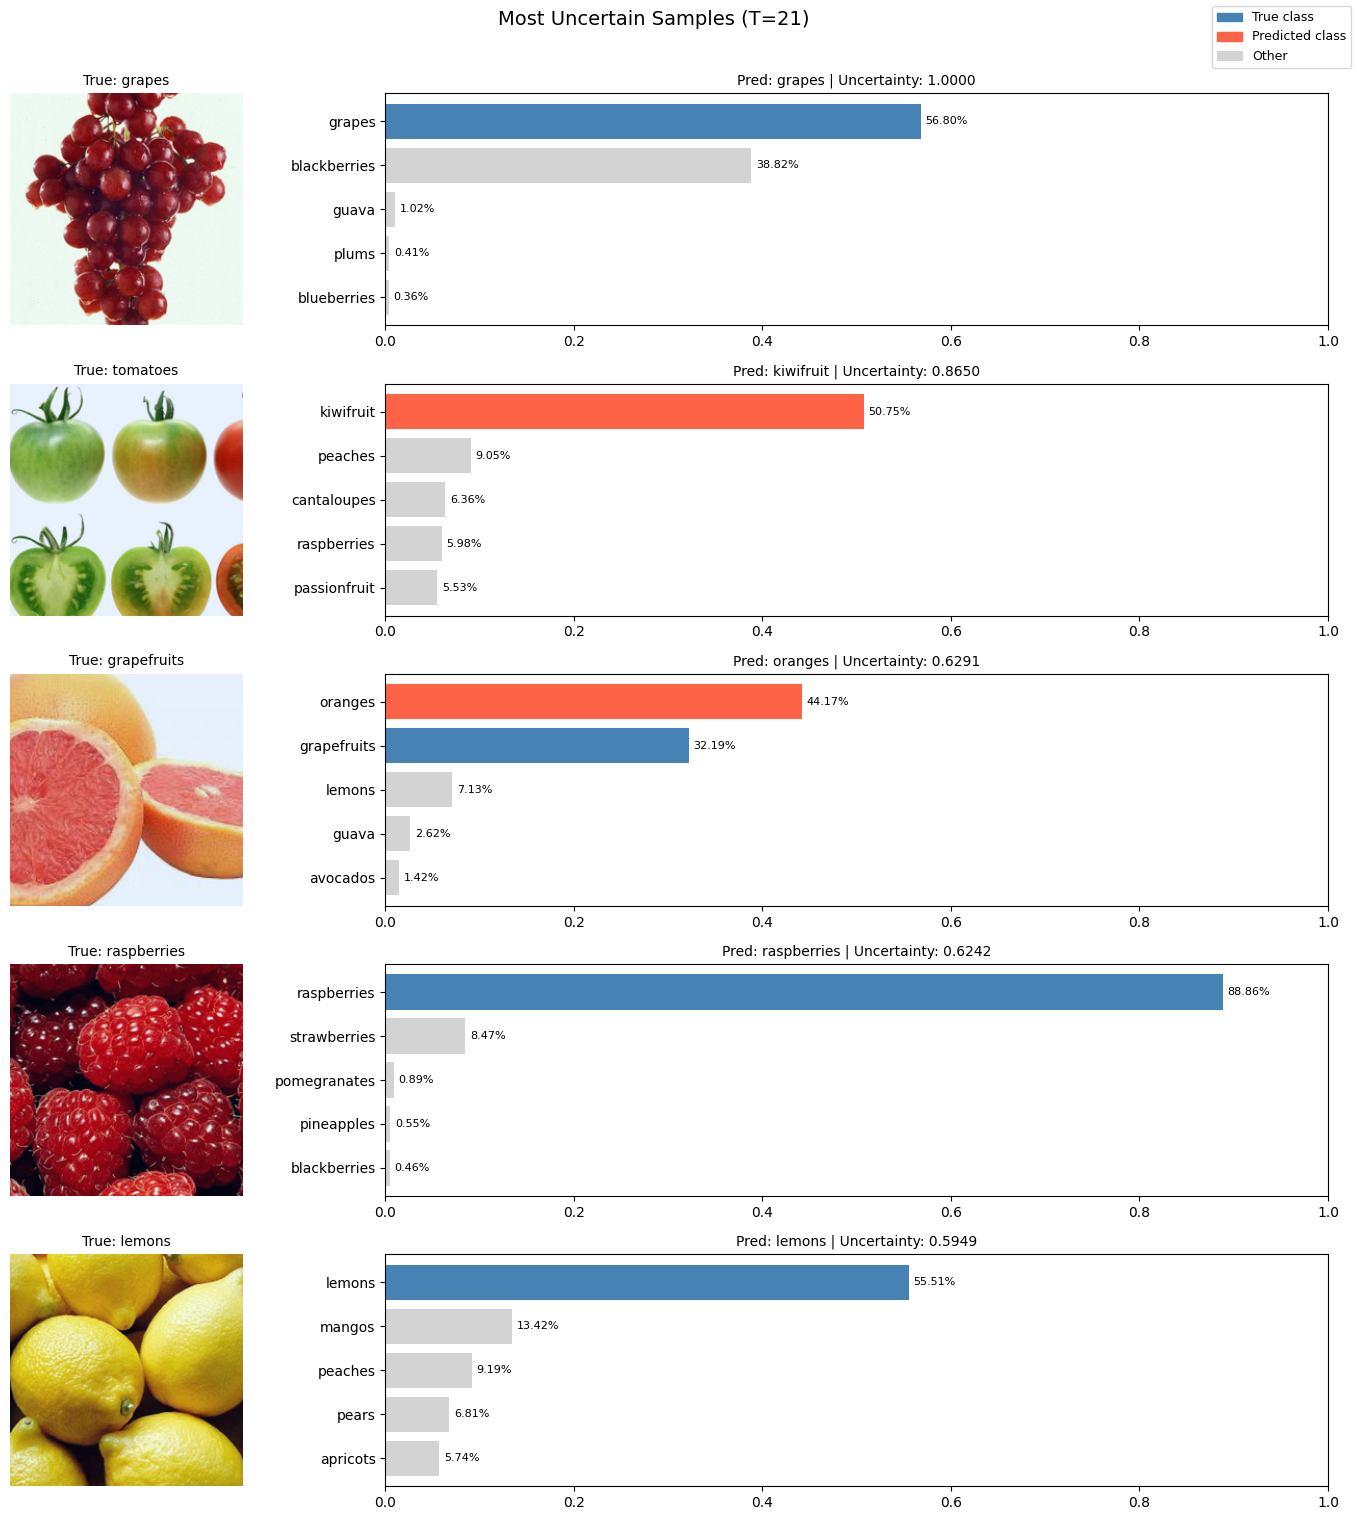

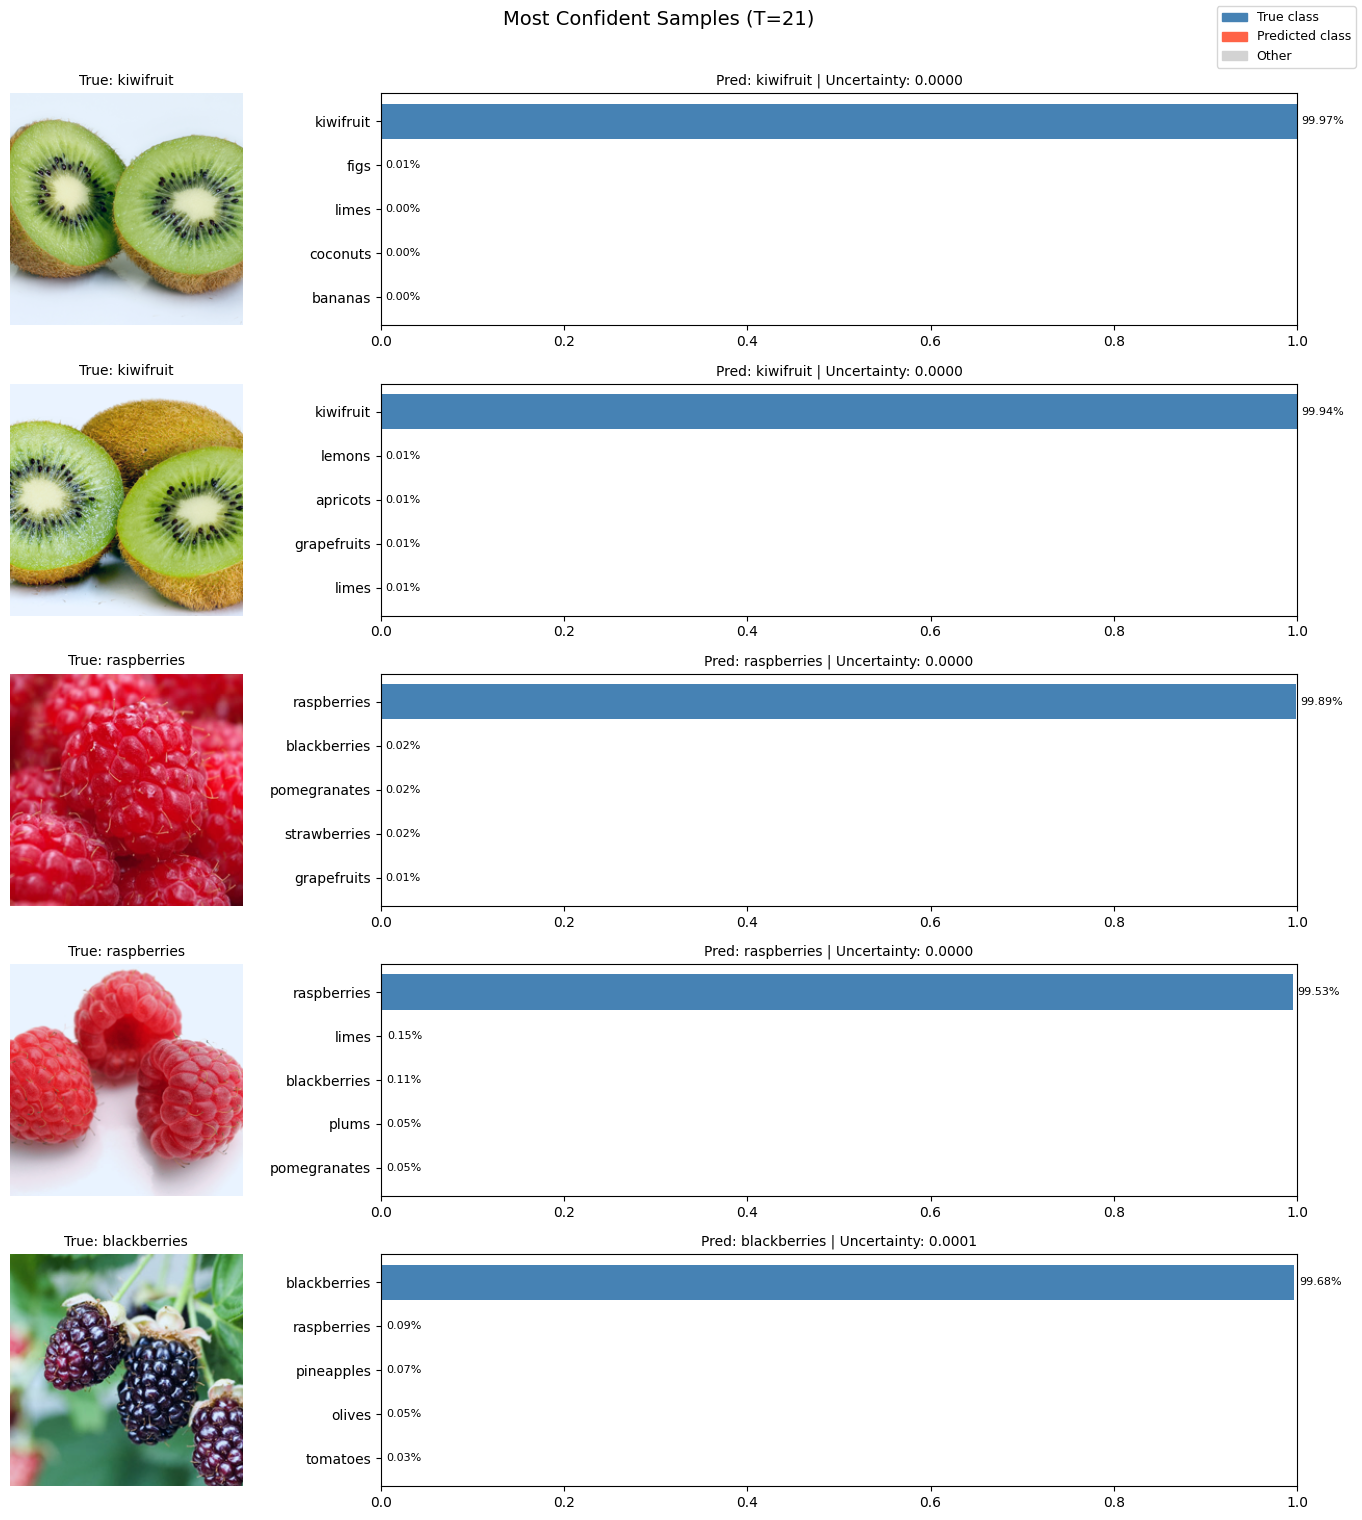

In [7]:
def denorm_image(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# Collect raw images for display
all_images = []
for images, _ in test_loader:
    all_images.append(images)
all_images = torch.cat(all_images)

variance = res["pred_variance"]

# Top 5 most uncertain and top 5 most confident
most_uncertain = variance.argsort(descending=True)[:5]
most_confident = variance.argsort()[:5]

def plot_mc_samples(indices, title):
    n = len(indices)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3 * n),
                             gridspec_kw={"width_ratios": [1, 3]})
    fig.suptitle(title, fontsize=14, y=1.01)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, idx in enumerate(indices):
        true_label = all_labels[idx].item()
        pred_label = res["preds"][idx].item()
        mean_p = res["mean_probs"][idx]
        var = variance[idx].item()

        # Top 5 classes by mean probability
        top5_idx = mean_p.argsort(descending=True)[:5]
        top5_names = [class_names[i] for i in top5_idx]
        top5_probs = mean_p[top5_idx].numpy()

        colors = []
        for i in top5_idx:
            if i == true_label and i == pred_label:
                colors.append('steelblue')
            elif i == pred_label:
                colors.append('tomato')
            elif i == true_label:
                colors.append('steelblue')
            else:
                colors.append('lightgray')

        axes[row, 0].imshow(denorm_image(all_images[idx]))
        axes[row, 0].set_title(f"True: {class_names[true_label]}", fontsize=10)
        axes[row, 0].axis('off')

        bars = axes[row, 1].barh(top5_names[::-1], top5_probs[::-1], color=colors[::-1])
        for bar, val in zip(bars, top5_probs[::-1]):
            axes[row, 1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                              f"{val:.2%}", va='center', fontsize=8)
        axes[row, 1].set_xlim(0, 1)
        axes[row, 1].set_title(f"Pred: {class_names[pred_label]} | Uncertainty: {var:.4f}", fontsize=10)

    from matplotlib.patches import Patch
    legend_elements = [Patch(color='steelblue', label='True class'),
                       Patch(color='tomato', label='Predicted class'),
                       Patch(color='lightgray', label='Other')]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_mc_samples(most_uncertain, f"Most Uncertain Samples (T={T_best})")
plot_mc_samples(most_confident, f"Most Confident Samples (T={T_best})")

## 7. Uncertainty Convergence Across T

How stable are uncertainty estimates as we increase T? Plot mean normalized variance per T value.

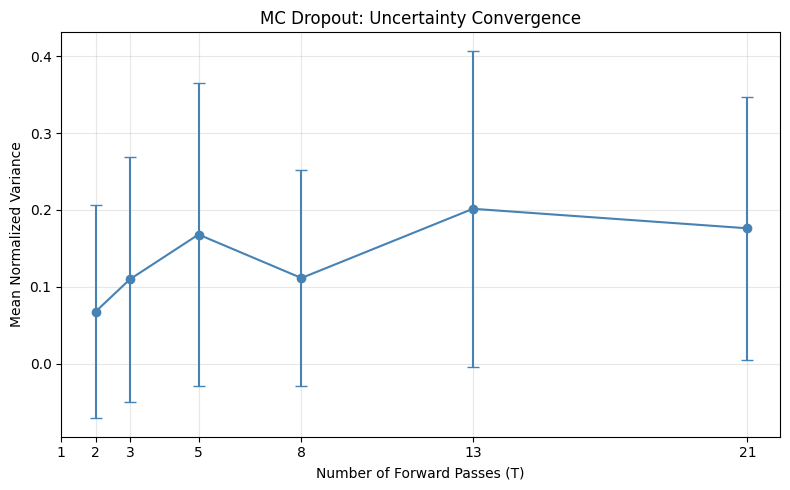

In [8]:
mean_variances = [mc_results[T]["pred_variance"].mean().item() for T in T_VALUES]
std_variances = [mc_results[T]["pred_variance"].std().item() for T in T_VALUES]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(T_VALUES, mean_variances, yerr=std_variances, marker='o', capsize=4, color='steelblue')
ax.set_xlabel("Number of Forward Passes (T)")
ax.set_ylabel("Mean Normalized Variance")
ax.set_title("MC Dropout: Uncertainty Convergence")
ax.set_xticks(T_VALUES)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Ranking Stability Across T

How does the uncertainty ranking of samples change as T increases? We track the top-5 most uncertain
and top-5 most confident sample IDs across all T values.

In [9]:
import pandas as pd

K = 5

# Collect top-K most/least uncertain sample indices per T
rows_uncertain = []
rows_confident = []
for T in T_VALUES:
    var = mc_results[T]["pred_variance"]
    top_uncertain = var.argsort(descending=True)[:K].tolist()
    top_confident = var.argsort()[:K].tolist()
    rows_uncertain.append([T] + top_uncertain)
    rows_confident.append([T] + top_confident)

cols = ["T"] + [f"Rank {i+1}" for i in range(K)]

df_uncertain = pd.DataFrame(rows_uncertain, columns=cols).set_index("T")
df_confident = pd.DataFrame(rows_confident, columns=cols).set_index("T")

print("=== Top-5 Most Uncertain Samples (by sample index) ===")
print(df_uncertain.to_string())
print(f"\n=== Top-5 Most Confident Samples (by sample index) ===")
print(df_confident.to_string())

# Check how stable the top-K set is: Jaccard similarity with the final T
final_uncertain = set(df_uncertain.loc[T_VALUES[-1]])
final_confident = set(df_confident.loc[T_VALUES[-1]])

print(f"\n=== Ranking Overlap with T={T_VALUES[-1]} (Jaccard) ===")
print(f"{'T':>4s}  {'Uncertain':>10s}  {'Confident':>10s}")
for T in T_VALUES:
    unc_set = set(df_uncertain.loc[T])
    conf_set = set(df_confident.loc[T])
    jacc_unc = len(unc_set & final_uncertain) / len(unc_set | final_uncertain)
    jacc_conf = len(conf_set & final_confident) / len(conf_set | final_confident)
    print(f"{T:4d}  {jacc_unc:10.2%}  {jacc_conf:10.2%}")

=== Top-5 Most Uncertain Samples (by sample index) ===
    Rank 1  Rank 2  Rank 3  Rank 4  Rank 5
T                                         
1      134     122     123     124     125
2       41      57      50     186      40
3       74     177      73      77      27
5       11      71     108      73     186
8       78     191      81     171     108
13      11     108      77     187      81
21      78     186      73     164     100

=== Top-5 Most Confident Samples (by sample index) ===
    Rank 1  Rank 2  Rank 3  Rank 4  Rank 5
T                                         
1      134     122     123     124     125
2        0      45      48     155     151
3       86     161     168      35      56
5      100     166     162      91      29
8       91      42      94     166      36
13     166      94      42     162      36
21      94      91     166     162      36

=== Ranking Overlap with T=21 (Jaccard) ===
   T   Uncertain   Confident
   1       0.00%       0.00%
   2      11